# Modulo 01: Caracteristicas de la Vivienda y del Hogar (ENAHO 2025)

Este notebook ejecuta el pipeline automatizado y validado definido en `src/`:
- **Filtro geografico:** Lima y Callao (UBIGEO 07 y 15).
- **Filtro de cobertura:** Entrevistas completas y validas (RESULT in [1, 2]).
- **Resolucion de nulos estructurales:** Imputacion intra-vivienda para hogares secundarios (HOGAR > 11).
- **Ingenieria de Caracteristicas:** Consolidacion de tenencia y SUNARP (seguridad_tenencia).
- **Validaciones estrictas:** Esquema de columnas, recuento de filas y unicidad de llave primaria.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar directorio raiz del proyecto para importar src
ROOT_DIR = Path.cwd().parents[1] if Path.cwd().name.startswith(('1031', '966')) else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.processors.modulo01 import Modulo01Processor

In [2]:
# Instanciar el procesador y ejecutar el pipeline con validaciones automaticas
processor = Modulo01Processor(
    file_path='Enaho01-2025-100.csv',
    year=2025,
    output_path='Enaho01-2025-100_cleaned.csv'
)

df = processor.process()
display(df.shape)
display(df.head(10))

[Modulo01Processor - 2025] Starting processing from: Enaho01-2025-100.csv
[Modulo01Processor - 2025] Detected delimiter: ';' for Enaho01-2025-100.csv
[Modulo01Processor - 2025] Raw data loaded: 44599 rows, 336 columns.
[Modulo01Processor - 2025] After scope filters: 5589 rows, 336 columns.
[Modulo01Processor - 2025] Exported clean dataset to: Enaho01-2025-100_cleaned.csv
[Modulo01Processor - 2025] Processing successfully completed: 5589 rows, 22 columns.


(5589, 22)

ubigeo  resultado_encuesta  \
conglomerado vivienda hogar                               
16166        23       11     070104                   2   
             40       11     070104                   2   
             89       11     070104                   2   
             127      11     070104                   2   
             142      11     070104                   2   
             153      11     070104                   2   
16187        22       11     070101                   2   
             47       12     070101                   2   
                      22     070101                   2   
             72       11     070101                   2   

                                     tipo_vivienda  material_pared_exterior  \
conglomerado vivienda hogar                                                   
16166        23       11        casa_independiente  ladrillo_bloque_cemento   
             40       11        casa_independiente  ladrillo_bloque_cemento   
             89       11        casa_independiente  ladrillo_bloque_cemento   
             127      11     departamento_edificio  ladrillo_bloque_cemento   
             142      11        casa_independiente  ladrillo_bloque_cemento   
             153      11        casa_independiente  ladrillo_bloque_cemento   
16187        22       11     departamento_edificio  ladrillo_bloque_cemento   
             47       12        casa_independiente  ladrillo_bloque_cemento   
                      22        casa_independiente  ladrillo_bloque_cemento   
             72       11        casa_independiente  ladrillo_bloque_cemento   

                                       material_piso  total_habitaciones  \
conglomerado vivienda hogar                                                
16166        23       11     loseta_terrazo_ceramico                 2.0   
             40       11     loseta_terrazo_ceramico                 6.0   
             89       11     loseta_terrazo_ceramico                 4.0   
             127      11                     cemento                 2.0   
             142      11     loseta_terrazo_ceramico                 3.0   
             153      11       parquet_madera_pulida                 7.0   
16187        22       11                     cemento                 3.0   
             47       12                     cemento                 7.0   
                      22                     cemento                 7.0   
             72       11                     cemento                 3.0   

                             total_dormitorios  tenencia_vivienda  \
conglomerado vivienda hogar                                         
16166        23       11                   1.0                1.0   
             40       11                   4.0                4.0   
             89       11                   3.0                2.0   
             127      11                   1.0                1.0   
             142      11                   2.0                2.0   
             153      11                   4.0                2.0   
16187        22       11                   2.0                2.0   
             47       12                   4.0                6.0   
                      22                   4.0                6.0   
             72       11                   2.0                6.0   

                             titulo_propiedad  registro_sunarp  ...  \
conglomerado vivienda hogar                                     ...   
16166        23       11                  NaN              NaN  ...   
             40       11                  1.0              1.0  ...   
             89       11                  1.0              1.0  ...   
             127      11                  NaN              NaN  ...   
             142      11                  1.0              1.0  ...   
             153      11                  1.0              1.0  ...   
16187        22       11                  1.0              1.

In [8]:
# Reporte de Nulos y Calidad de Datos
null_summary = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().mean() * 100).round(2)
})
display(null_summary[null_summary['Nulos'] > 0] if (df.isnull().sum() > 0).any() else '¡0% NULOS EN TODAS LAS VARIABLES!')

,Nulos,Porcentaje (%)
titulo_propiedad,1827,32.69
registro_sunarp,3194,57.15
agua_todos_los_dias,484,8.66
combustible_cocina,81,1.45


In [9]:
# Estadisticas Descriptivas
display(df.describe(include=[np.number]))
display(df.describe(include=['category']))

,resultado_encuesta,total_habitaciones,total_dormitorios,tenencia_vivienda,titulo_propiedad,registro_sunarp,tiene_tv_cable,tiene_internet
count,5589.000000,5589.000000,5589.000000,5589.000000,3762.000000,2395.000000,5589.0,5589.0
mean,1.593487,3.486312,2.303453,2.667919,1.430888,1.099374,0.0,0.0
std,0.491226,1.562822,1.126036,1.655432,0.616733,0.369215,0.0,0.0
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0
25%,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.0,0.0
50%,2.000000,3.000000,2.000000,2.000000,1.000000,1.000000,0.0,0.0
75%,2.000000,4.000000,3.000000,3.000000,2.000000,1.000000,0.0,0.0
max,2.000000,12.000000,9.000000,7.000000,3.000000,9.000000,0.0,0.0


,ubigeo,tipo_vivienda,material_pared_exterior,material_piso,fuente_agua,agua_todos_los_dias,conexion_bano,combustible_cocina,vivienda_inadecuada,vivienda_hacinamiento,vivienda_sin_bano,nino_sin_educacion,dependencia_economica,seguridad_tenencia
count,5589,5589,5589,5589,5589,5105,5589,5508,5589,5589,5589,5589,5589,5589
unique,119,6,9,7,8,2,8,7,2,2,2,2,2,1
top,070101,casa_independiente,ladrillo_bloque_cemento,cemento,red_interior,todos_los_dias,red_interior,gas_glp,adecuada,no_hacinada,con_bano,asiste,baja_dependencia,propia_sin_titulo
freq,433,4351,4310,2635,4887,4898,4672,3148,5368,5442,5406,5571,5579,5589


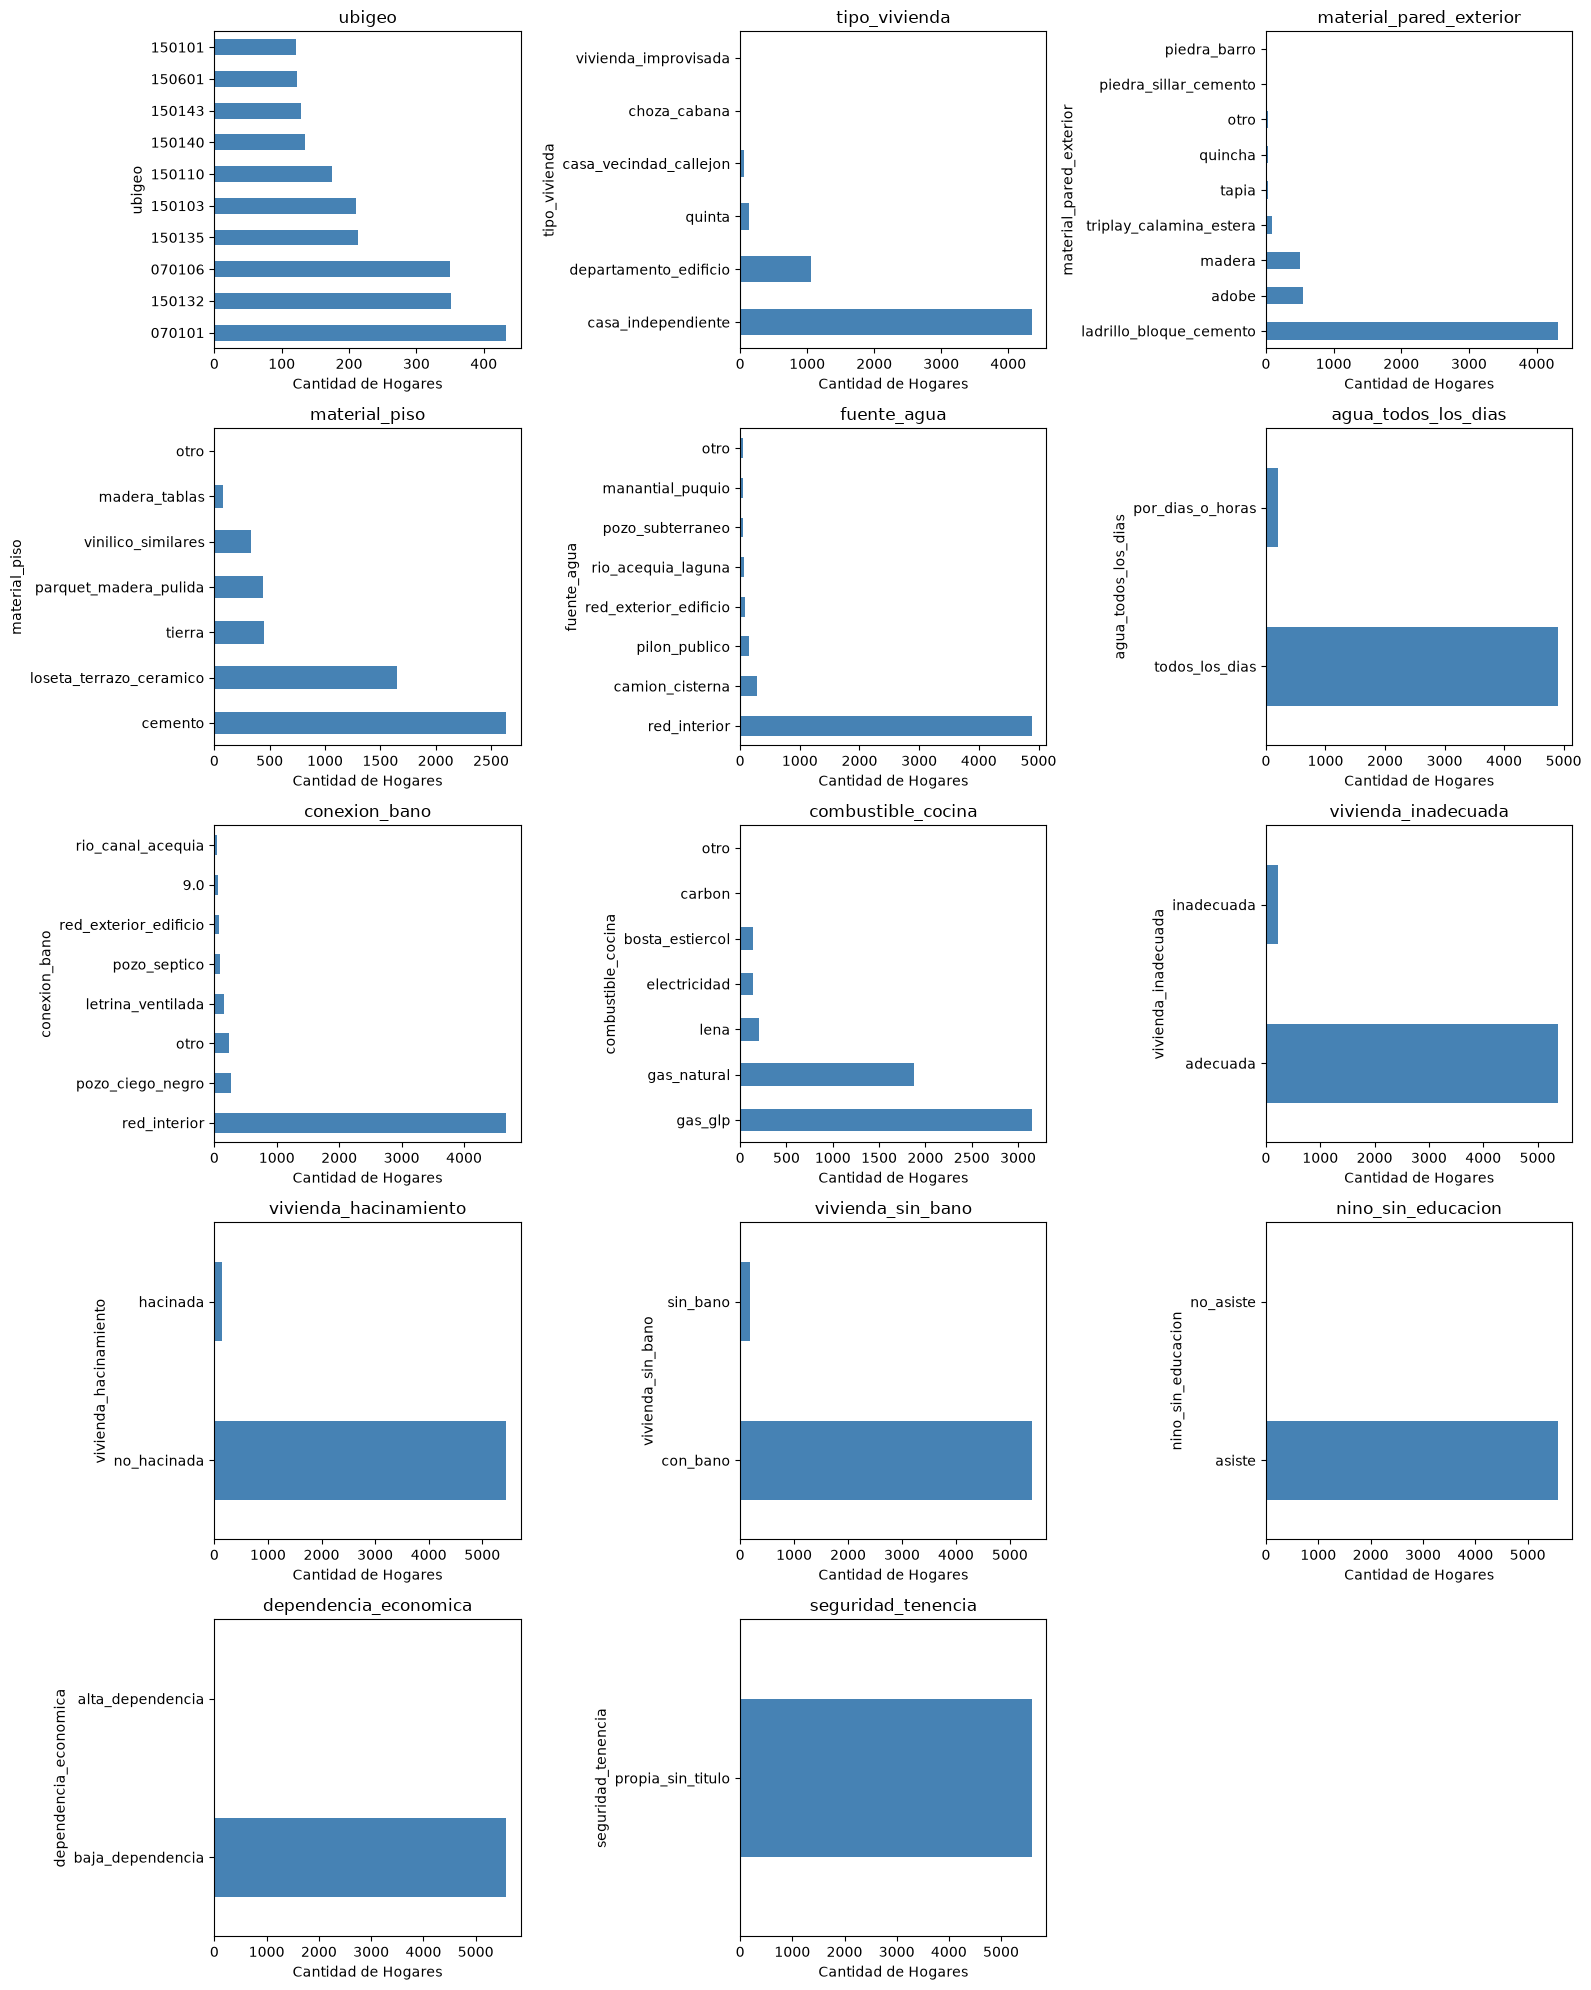

In [12]:
# EDA Visual: Distribucion de Variables Categoricas
cat_cols = df.select_dtypes(include='category').columns.tolist()
n_cols = len(cat_cols)
n_plots_x = 3
n_plots_y = int(np.ceil(n_cols / n_plots_x))

fig, axes = plt.subplots(nrows=n_plots_y, ncols=n_plots_x, figsize=(16, 4 * n_plots_y))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot(kind='barh', ax=axes[i], color='steelblue', title=col)
    axes[i].set_xlabel('Cantidad de Hogares')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

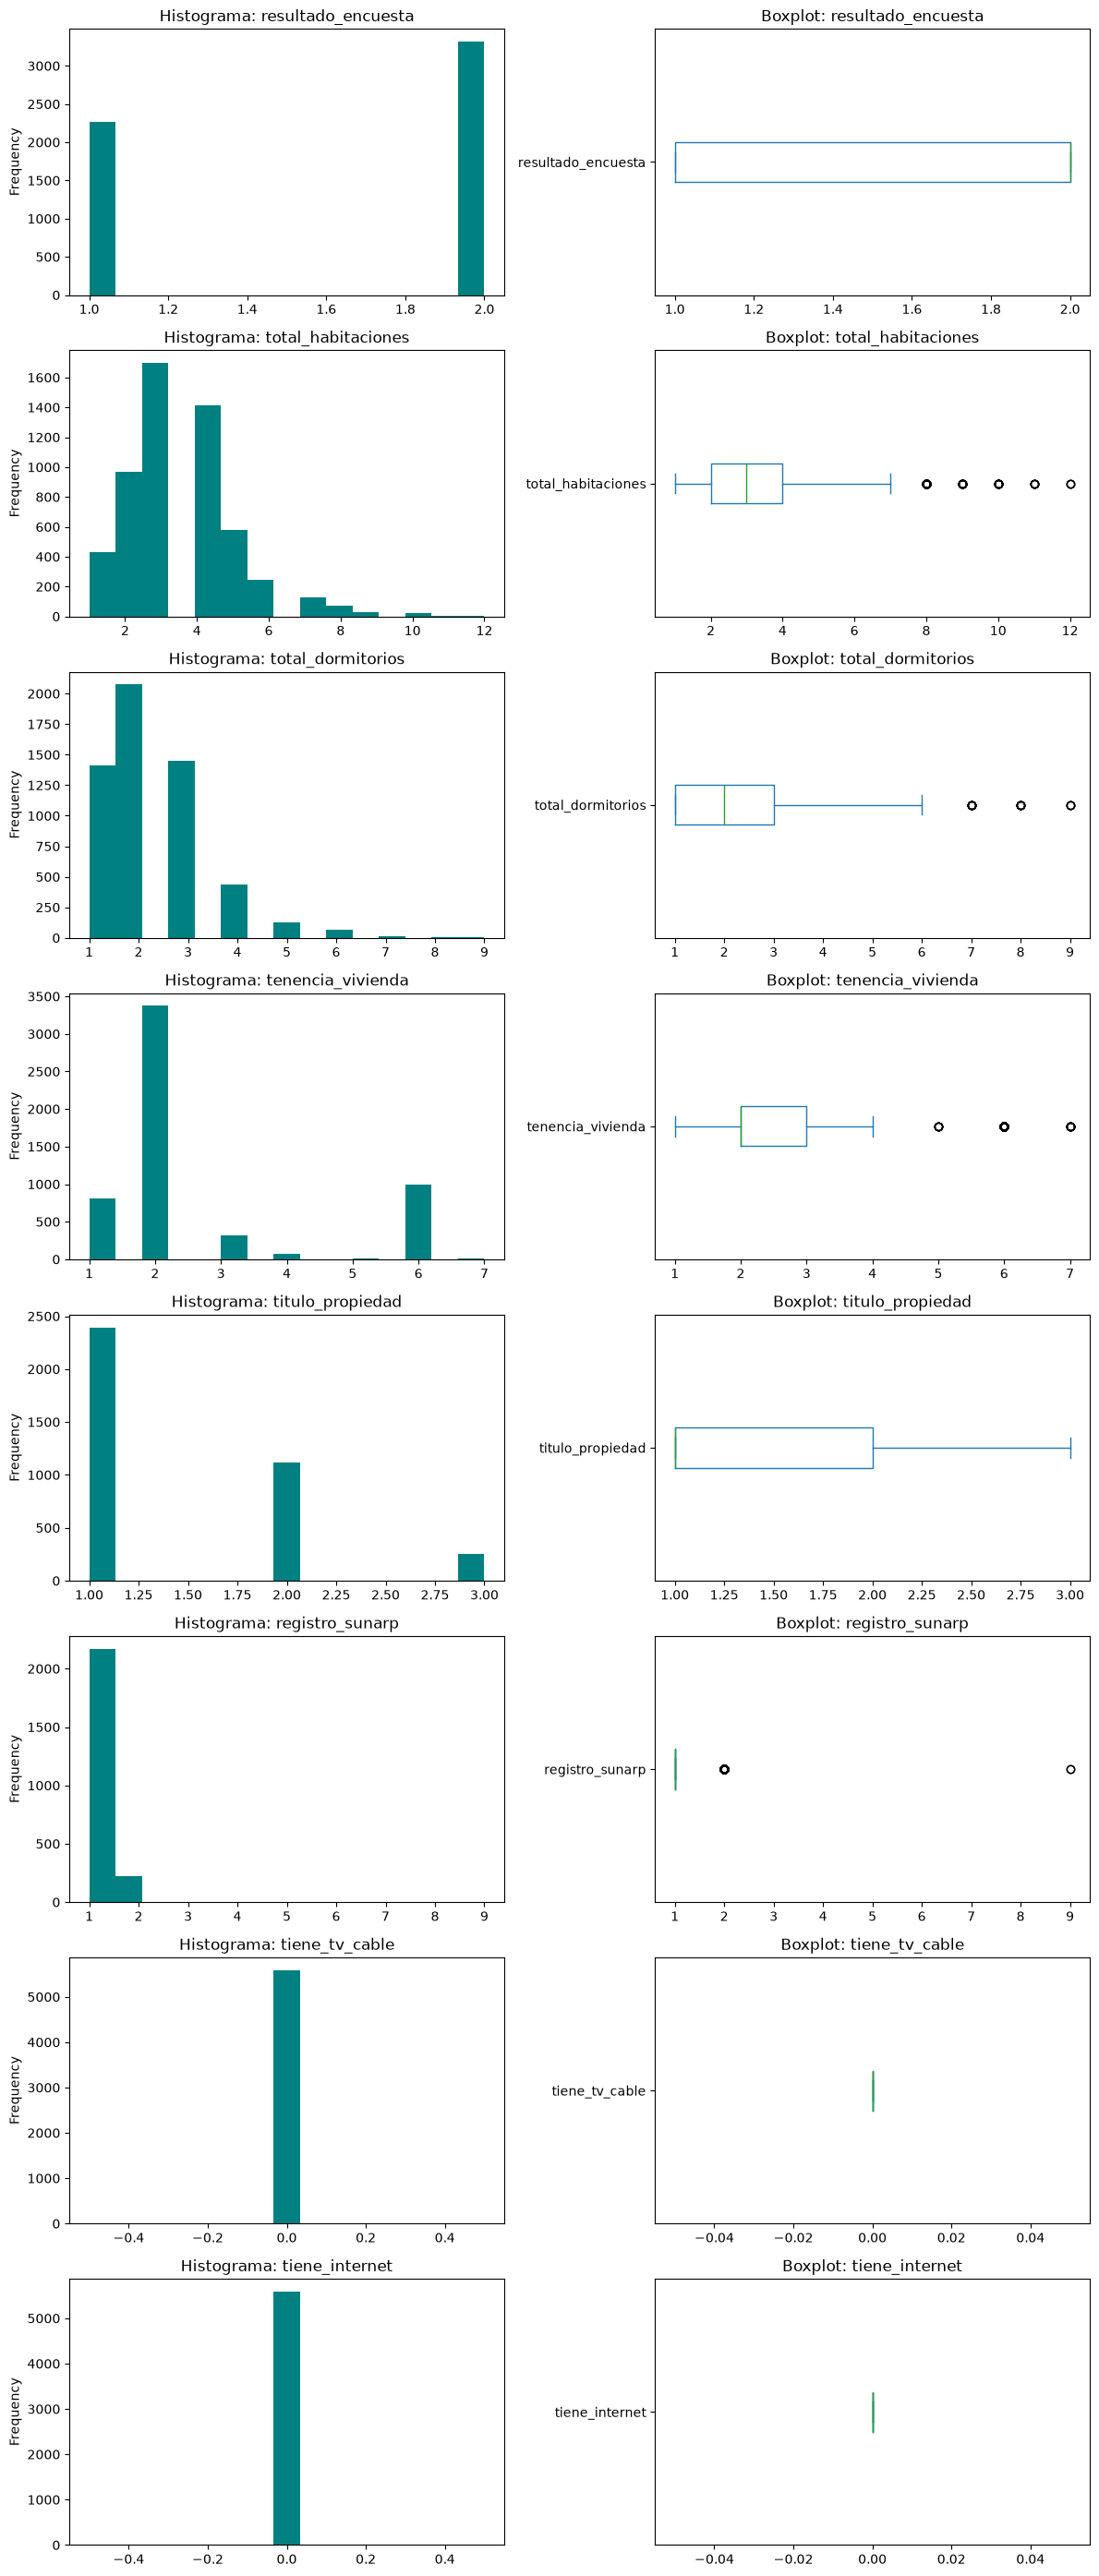

In [15]:
# EDA Visual: Variables Numericas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, 3.5 * len(num_cols)))
if len(num_cols) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', bins=15, ax=axes[i, 0], color='teal', title=f'Histograma: {col}')
    df[col].plot(kind='box', vert=False, ax=axes[i, 1], title=f'Boxplot: {col}')

plt.tight_layout()
plt.show()